# 7. To apply ML model of your choice on Advertisement Budget dataset  for best budget prediction

## Load Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Advertising Budget and Sales.csv")
df

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [3]:
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.tail()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [5]:
df.shape

(200, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df.dtypes

Unnamed: 0                   int64
TV Ad Budget ($)           float64
Radio Ad Budget ($)        float64
Newspaper Ad Budget ($)    float64
Sales ($)                  float64
dtype: object

In [8]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## Data Cleaning

In [9]:
df.isnull()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


In [10]:
df.isnull().sum()

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

In [11]:
df.drop(columns = 'Unnamed: 0' ,inplace=True,axis=1)

## EDA

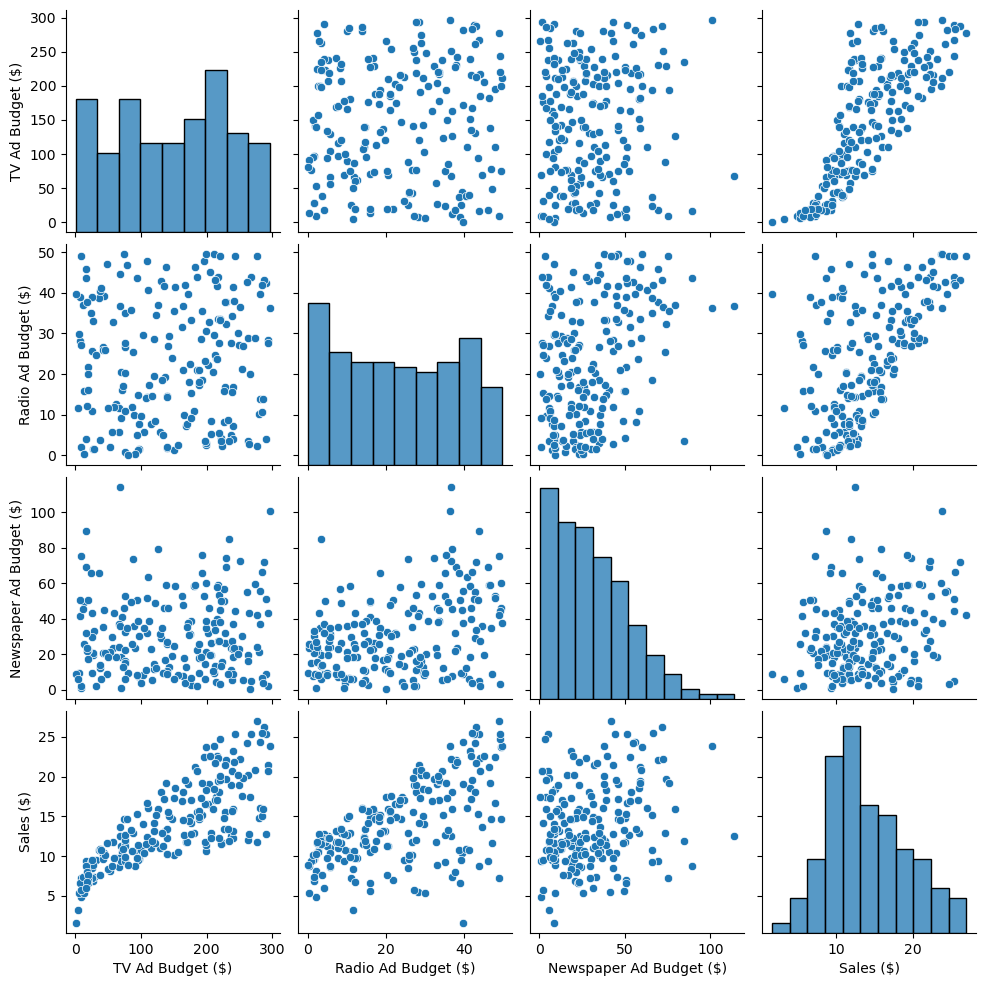

In [12]:
sns.pairplot(data=df)

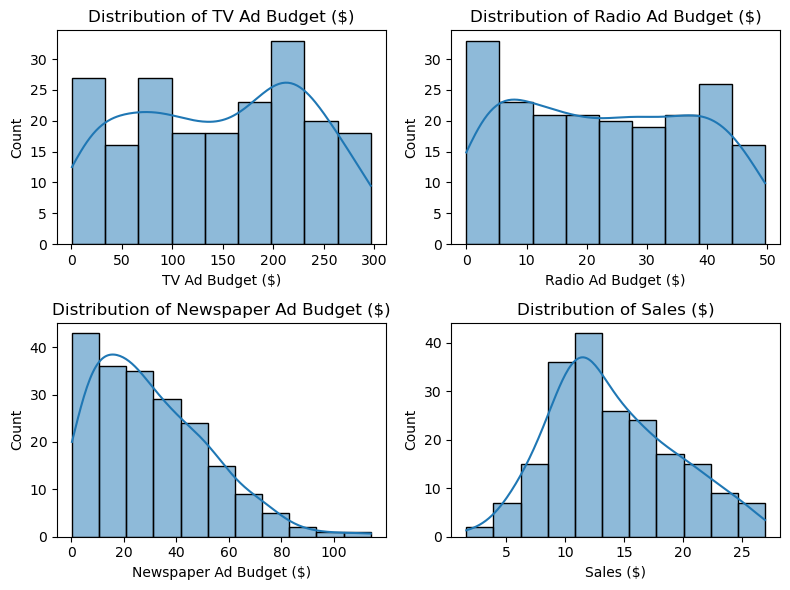

In [13]:
# List of features for univariate analysis
features = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']

plt.figure(figsize=(8, 6))

# Loop through features to create histograms
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

plt.savefig("Distributions of features")
plt.tight_layout()
plt.show()

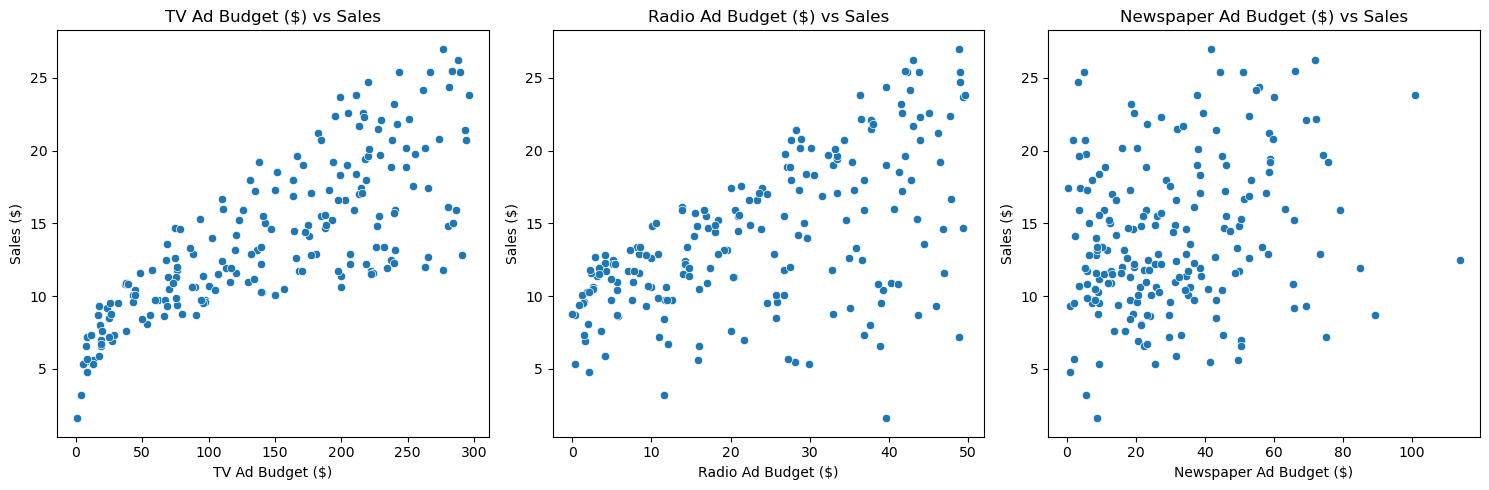

In [14]:
# List of features to compare with Sales
advertising_features = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']

plt.figure(figsize=(15, 5))

# Loop through features to create scatter plots
for i, feature in enumerate(advertising_features, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=feature, y='Sales ($)', data=df)
    plt.title(f'{feature} vs Sales')

plt.savefig("Features Vs Sales")
plt.tight_layout()
plt.show()

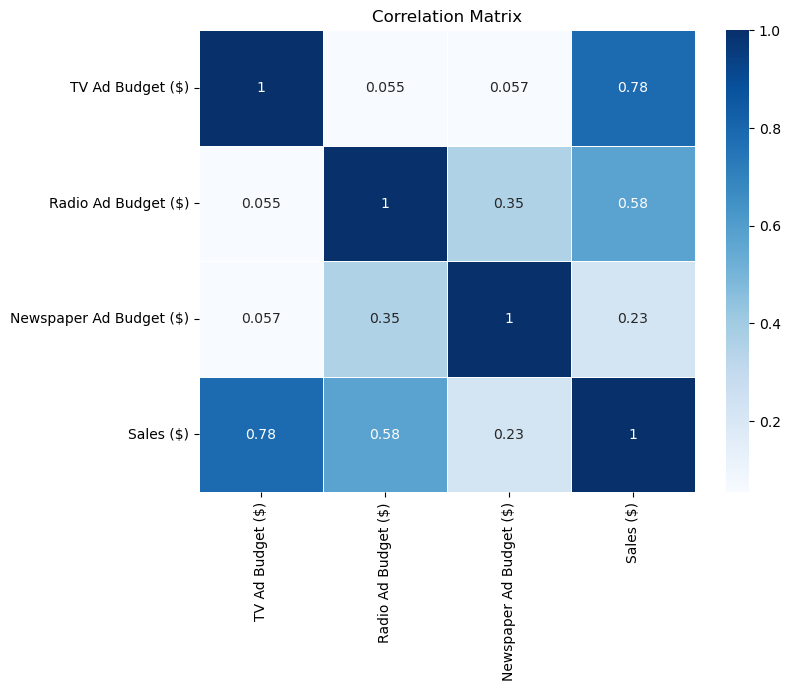

In [15]:
# Correlation Matrix and Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', linewidths=0.5)
plt.title('Correlation Matrix')
plt.savefig("Correlation Matrix Between Features")
plt.show()

<Axes: ylabel='TV Ad Budget ($)'>

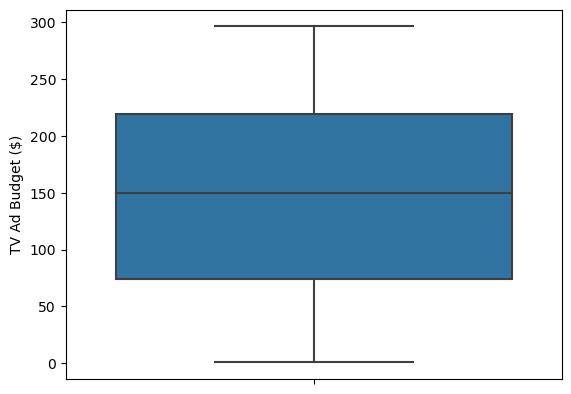

In [16]:
sns.boxplot(y=df['TV Ad Budget ($)'])

<Axes: ylabel='Radio Ad Budget ($)'>

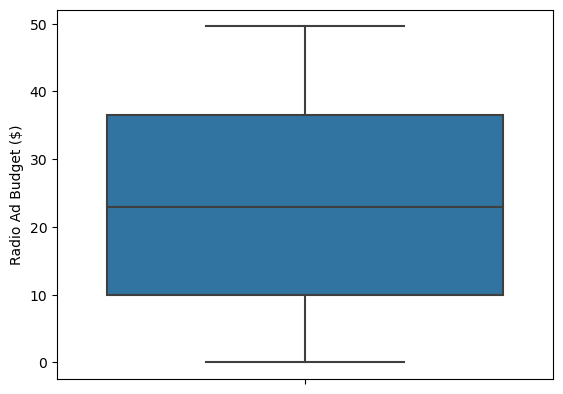

In [17]:
sns.boxplot(y=df['Radio Ad Budget ($)'])

<Axes: ylabel='Newspaper Ad Budget ($)'>

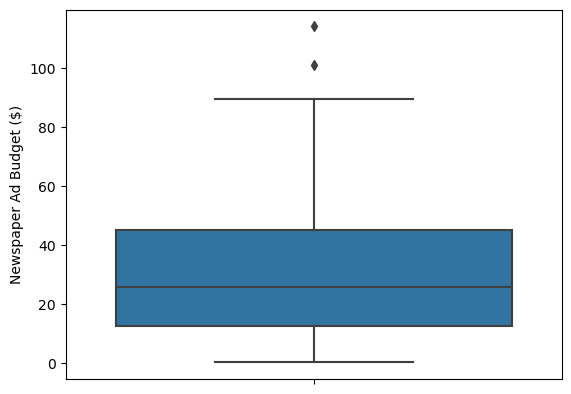

In [18]:
sns.boxplot(y=df['Newspaper Ad Budget ($)'])

<Axes: ylabel='Sales ($)'>

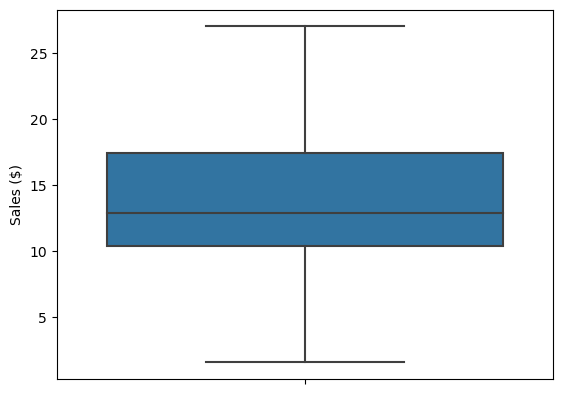

In [19]:
sns.boxplot(y=df['Sales ($)'])

## Train-Test Split

In [20]:
# Define features and target variable
X = df.drop('Sales ($)', axis=1)  # Features
y = df['Sales ($)']  

In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Display the shapes of the resulting datasets
print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (160, 3), (160,)
Testing data shape: (40, 3), (40,)


## Model Training

In [23]:
model = RandomForestRegressor()

In [24]:
# Fit the model
model.fit(X_train, y_train)

RandomForestRegressor()

In [25]:
 # Make predictions on training and testing data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [26]:
# Calculate performance metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
print("Train MAE: ", train_mae)
train_mse = mean_squared_error(y_train, y_train_pred)
print("Train MSE: ", train_mse)
train_r2 = r2_score(y_train, y_train_pred)
print("Train R2 Score: ", train_r2)
train_accuracy = int(train_r2 * 100)
print("Training Accuracy: ", train_accuracy)

Train MAE:  0.23096874999999972
Train MSE:  0.10203679374999988
Train R2 Score:  0.996065861728276
Training Accuracy:  99


In [27]:
# Calculate performance metrics for testing data
test_mae = mean_absolute_error(y_test, y_test_pred)
print("Test MAE", test_mae)
test_mse = mean_squared_error(y_test, y_test_pred)
print("Test MSE", test_mse)
test_r2 = r2_score(y_test, y_test_pred)
print("Test R2 Score", test_r2)
test_accuracy = int(test_r2 * 100)
print("Testing Accuracy: ", test_accuracy)

Test MAE 0.6426250000000004
Test MSE 0.6284506250000033
Test R2 Score 0.9800893830411816
Testing Accuracy:  98
